**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 6**
Ingeniería de características (FE)

---

*   NOMBRE: EDUARDO MIGUEL PAZ CALVOPIÑA
*   MATRÍCULA: A00886517

En esta actividad trabajarás con el archivo `computer_prices.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de computadoras portátiles y de escritorio, disponible en Kaggle.

Los datos fueron recopilados para analizar el rendimiento y el precio de los dispositivos, e incluyen información sobre hardware, almacenamiento, conectividad y otras especificaciones técnicas. Los indicadores incluidos son:

* `device_type`: Tipo de dispositivo (ej. laptop, desktop)
* `brand`: Marca del dispositivo
* `model`: Modelo del dispositivo
* `release_year`: Año de lanzamiento del dispositivo
* `os`: Sistema operativo instalado
* `form_factor`: Factor de forma o diseño del dispositivo (ej. laptop, ultrabook, desktop tower)
* `cpu_brand`: Marca del procesador
* `cpu_tier`: Nivel o gama del procesador, ordinal del 1 al 6 según desempeño
* `cpu_cores`: Número de núcleos del procesador
* `cpu_threads`: Número de hilos de ejecución del procesador
* `gpu_brand`: Marca de la tarjeta gráfica
* `gpu_model`: Modelo específico de la tarjeta gráfica
* `gpu_tier`: Nivel o gama de la GPU, ordinal del 1 al 6 según desempeño
* `vram_gb`: Memoria de video de la GPU en gigabytes
* `ram_gb`: Memoria RAM del dispositivo en gigabytes
* `storage_type`: Tipo de almacenamiento (ej. HDD, SSD)
* `storage_gb`: Capacidad de almacenamiento en gigabytes
* `storage_drive_count`: Número de unidades de almacenamiento instaladas
* `display_type`: Tipo de pantalla (ej. IPS, TN, OLED)
* `charger_watts`: Potencia del cargador (en watts) para laptops
* `psu_watts`: Potencia de la fuente de poder (en watts) para desktops
* `wifi`: Estándar de conectividad Wi-Fi (ej. Wi-Fi 5, 6, 6E, 7)
* `bluetooth`: Versión de Bluetooth
* `weight_kg`: Peso del dispositivo en kilogramos
* `warranty_months`: Meses de garantía del dispositivo
* `price`: Precio del dispositivo. Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [1]:
# Instalar las bibliotecas necesarias
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.0 MB/s eta 0:00:00


In [2]:
!pip install feature_engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 4.0 MB/s eta 0:00:00


In [3]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from scipy.stats import probplot
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from category_encoders.binary import BinaryEncoder
import datetime

1. Descarga el archivo: `computer_prices.csv` y guarda, en un dataframe (`compu_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Determina la cantidad de valores únicos por columna.
* Elimina las variables:
  * `model`: Debido a su altísima cardinalidad, lo que dificulta su uso en análisis y modelado.
  * `cpu_model`: Además de su elevada cardinalidad, su información ya está representada de manera implícita en otras variables como: `cpu_tier`, `cpu_cores` y `cpu_threads`

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/MIAA/6.1 Ingeniería de características/Activity 6"
os.chdir(DIR)

In [6]:
compu_df = pd.read_csv('computer_prices.csv')
compu_df.head()

,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,...,storage_gb,storage_drive_count,display_type,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,...,1024,1,LED,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,Samsung Pro KM8,2022,Windows,Mainstream,Intel,Intel i7-11114,4,12,...,512,1,OLED,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,...,512,2,LED,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,Dell Cube AXR,2024,Windows,ATX,AMD,AMD Ryzen 5 7550,2,6,...,512,2,IPS,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,Gigabyte Pro IX1,2024,Linux,Gaming,AMD,AMD Ryzen 7 6230,5,16,...,256,1,Mini-LED,90,0,Wi-Fi 6,5.2,1.50,12,2681.99


In [7]:
compu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   model                100000 non-null  object 
 3   release_year         100000 non-null  int64  
 4   os                   100000 non-null  object 
 5   form_factor          100000 non-null  object 
 6   cpu_brand            100000 non-null  object 
 7   cpu_model            100000 non-null  object 
 8   cpu_tier             100000 non-null  int64  
 9   cpu_cores            100000 non-null  int64  
 10  cpu_threads          100000 non-null  int64  
 11  gpu_brand            100000 non-null  object 
 12  gpu_model            100000 non-null  object 
 13  gpu_tier             100000 non-null  int64  
 14  vram_gb              100000 non-null  int64  
 15  ram_gb            

In [8]:
num_cols = compu_df.select_dtypes(include=['number']).columns
cat_cols = compu_df.select_dtypes(exclude=['number']).columns

print(f"Numerical columns ({len(num_cols)}): {list(num_cols)}")
print(f"Text/Categorical columns ({len(cat_cols)}): {list(cat_cols)}")

Numerical columns (15): ['release_year', 'cpu_tier', 'cpu_cores', 'cpu_threads', 'gpu_tier', 'vram_gb', 'ram_gb', 'storage_gb', 'storage_drive_count', 'charger_watts', 'psu_watts', 'bluetooth', 'weight_kg', 'warranty_months', 'price']
Text/Categorical columns (12): ['device_type', 'brand', 'model', 'os', 'form_factor', 'cpu_brand', 'cpu_model', 'gpu_brand', 'gpu_model', 'storage_type', 'display_type', 'wifi']


In [9]:
# Determinando la cantidad de valores únicos por columna
compu_df.nunique()

,0
device_type,2
brand,10
model,99036
release_year,8
os,4
form_factor,10
cpu_brand,3
cpu_model,26971
cpu_tier,6
cpu_cores,12


In [10]:
# Delete high-cardinality and redundant variables

compu_df.drop(columns=['model', 'cpu_model'], inplace=True)

In [11]:
compu_df.head(5)

,device_type,brand,release_year,os,form_factor,cpu_brand,cpu_tier,cpu_cores,cpu_threads,gpu_brand,...,storage_gb,storage_drive_count,display_type,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,2022,Windows,ATX,Intel,3,12,24,NVIDIA,...,1024,1,LED,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,2022,Windows,Mainstream,Intel,4,12,24,NVIDIA,...,512,1,OLED,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,2024,macOS,SFF,AMD,2,8,16,NVIDIA,...,512,2,LED,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,2024,Windows,ATX,AMD,2,6,12,AMD,...,512,2,IPS,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,2024,Linux,Gaming,AMD,5,16,32,NVIDIA,...,256,1,Mini-LED,90,0,Wi-Fi 6,5.2,1.50,12,2681.99


2. Antes de iniciar con el análisis univariado, verifica si hay valores duplicados y/o faltantes.
* Obtén las estadísticas descriptivas, separado las numéricas y las categóricas. De estas últimas incluye las tablas de frecuencia.
* Genera histogramas para las numéricas y diagramas de barras para las categóricas. Con alta cardinalidad, sólo incluye los 10 valores más frecuentes.

In [12]:
# Verificar si hay valores duplicados y/o faltantes.
print(f"Total duplicated records: {compu_df.duplicated().sum()}")
print("\nMissing values per column:")
print(compu_df.isna().sum())

Total duplicated records: 0

Missing values per column:
device_type            0
brand                  0
release_year           0
os                     0
form_factor            0
cpu_brand              0
cpu_tier               0
cpu_cores              0
cpu_threads            0
gpu_brand              0
gpu_model              0
gpu_tier               0
vram_gb                0
ram_gb                 0
storage_type           0
storage_gb             0
storage_drive_count    0
display_type           0
charger_watts          0
psu_watts              0
wifi                   0
bluetooth              0
weight_kg              0
warranty_months        0
price                  0
dtype: int64


No hay valores duplicados y no hay valores faltantes

In [13]:
print("\Variables numéricas - Estadísticas descriptivas:")
compu_df.describe().T

\Variables numéricas - Estadísticas descriptivas:


<>:1: SyntaxWarning: invalid escape sequence '\V'
<>:1: SyntaxWarning: invalid escape sequence '\V'
/tmp/ipython-input-2339517871.py:1: SyntaxWarning: invalid escape sequence '\V'
  print("\Variables numéricas - Estadísticas descriptivas:")


,count,mean,std,min,25%,50%,75%,max
release_year,100000.0,2022.320850,2.025761,2018.00,2021.00,2023.00,2024.00,2025.00
cpu_tier,100000.0,3.153490,1.373175,1.00,2.00,3.00,4.00,6.00
cpu_cores,100000.0,10.515740,5.044092,4.00,6.00,8.00,14.00,28.00
cpu_threads,100000.0,19.372700,9.718426,4.00,12.00,16.00,24.00,56.00
gpu_tier,100000.0,2.991350,1.459643,1.00,2.00,3.00,4.00,6.00
vram_gb,100000.0,6.152180,3.964926,0.00,4.00,6.00,8.00,16.00
ram_gb,100000.0,39.706400,31.902684,8.00,16.00,32.00,64.00,144.00
storage_gb,100000.0,903.936000,774.243654,256.00,512.00,512.00,1024.00,4096.00
storage_drive_count,100000.0,1.524980,0.797284,1.00,1.00,1.00,2.00,4.00
charger_watts,100000.0,61.383450,62.795034,0.00,0.00,65.00,90.00,240.00


In [14]:
# Estadísticas descriptivas de las variables de texto
compu_df.describe(include = ['object','category']).T

,count,unique,top,freq
device_type,100000,2,Laptop,59844
brand,100000,10,Lenovo,15992
os,100000,4,Windows,71817
form_factor,100000,10,Mainstream,17819
cpu_brand,100000,3,Intel,52774
gpu_brand,100000,4,NVIDIA,54712
gpu_model,100000,49,Apple Integrated,18922
storage_type,100000,4,NVMe,45059
display_type,100000,6,LED,32000
wifi,100000,4,Wi-Fi 6,46149


In [15]:
# Separar columnas
num_cols = compu_df.select_dtypes(include=['number']).columns
cat_cols = compu_df.select_dtypes(exclude=['number']).columns


In [16]:
print("\nTablas de frecuencia - variables categóricas:")
for col in cat_cols:
    print(col)
    print(compu_df[col].value_counts())
    print('-' * 50)


Tablas de frecuencia - variables categóricas:
device_type
device_type
Laptop     59844
Desktop    40156
Name: count, dtype: int64
--------------------------------------------------
brand
brand
Lenovo      15992
HP          14114
Dell        14005
Apple       11915
ASUS        10159
Acer         9925
Samsung      8066
MSI          7891
Gigabyte     4900
Razer        3033
Name: count, dtype: int64
--------------------------------------------------
os
os
Windows     71817
macOS       18207
Linux        6109
ChromeOS     3867
Name: count, dtype: int64
--------------------------------------------------
form_factor
form_factor
Mainstream     17819
Gaming         16876
ATX            15597
Ultrabook      13236
Micro-ATX       8672
Full-Tower      7110
2-in-1          7049
SFF             5585
Workstation     4864
Mini-ITX        3192
Name: count, dtype: int64
--------------------------------------------------
cpu_brand
cpu_brand
Intel    52774
AMD      35311
Apple    11915
Name: count, dtype

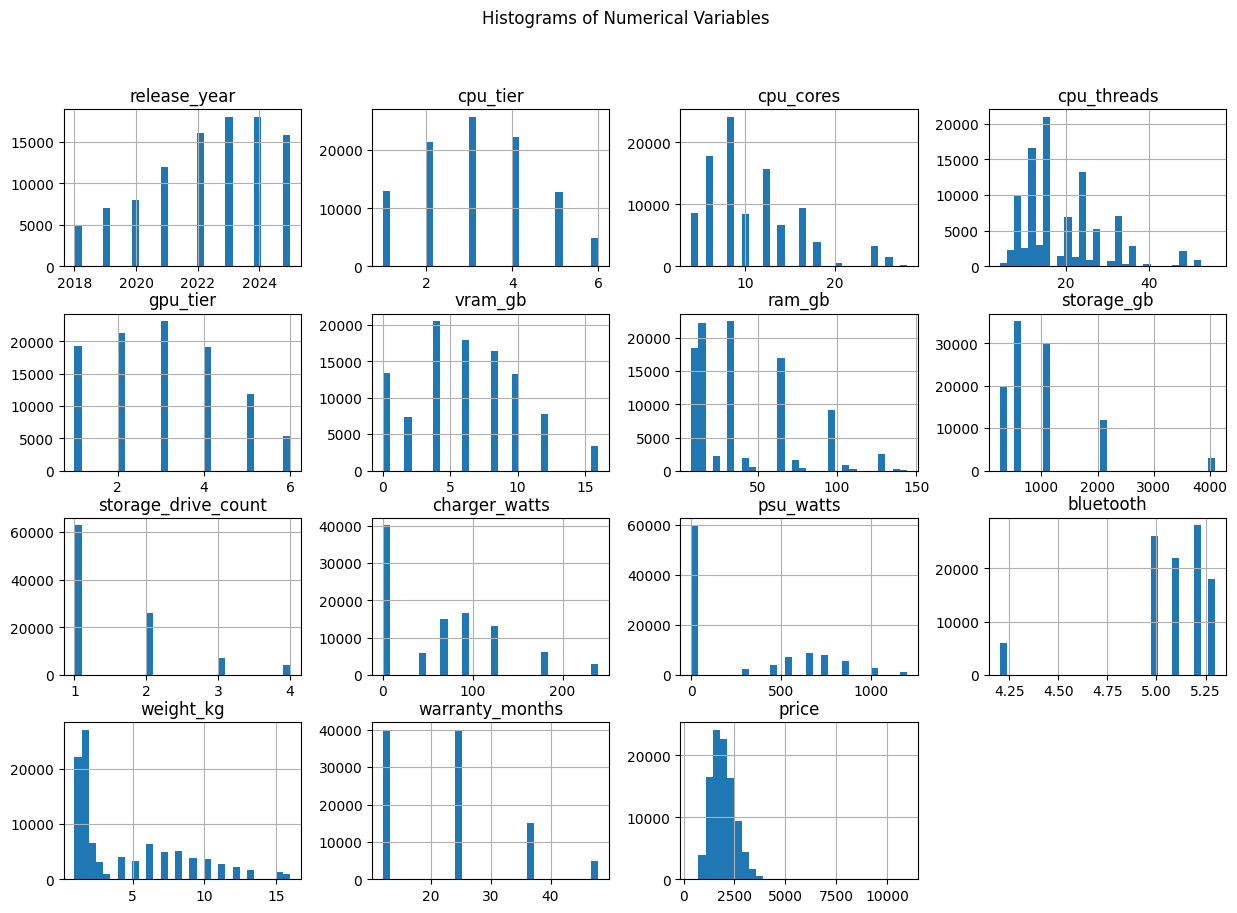

In [17]:
# Histograms for numerical variables
compu_df[num_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle("Histograms of Numerical Variables")
plt.show()

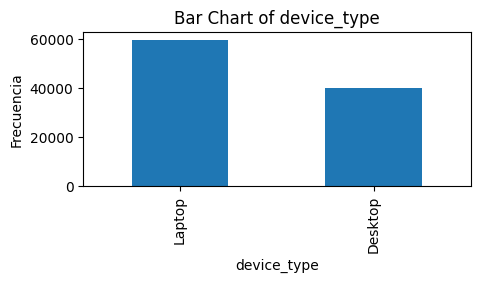

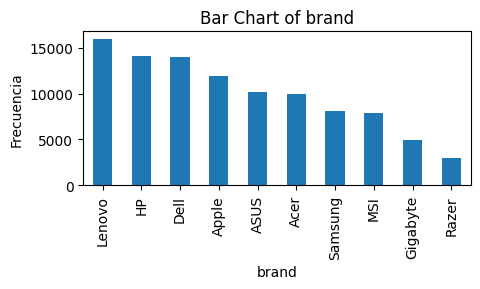

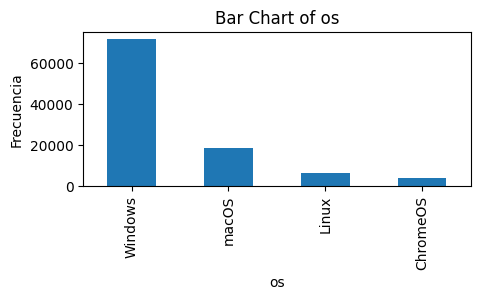

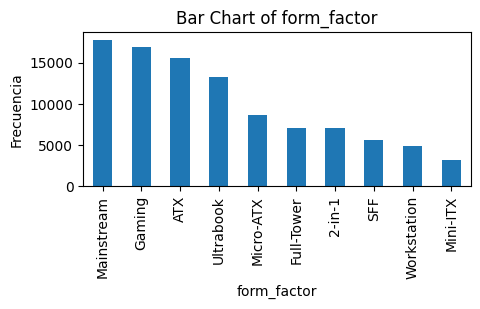

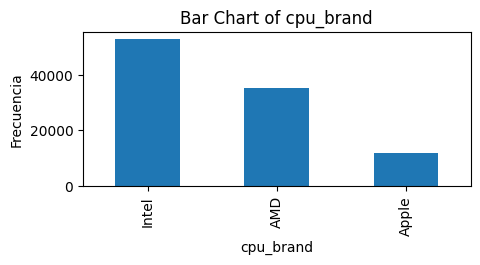

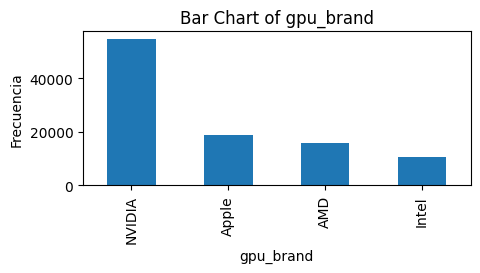

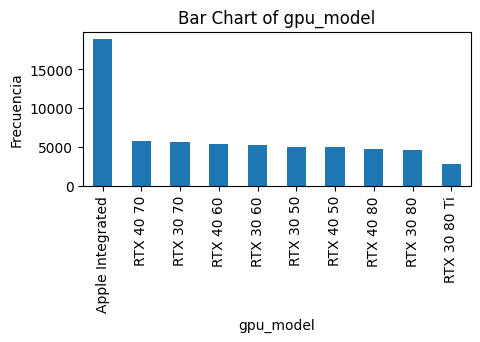

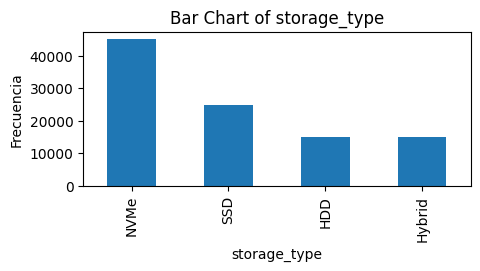

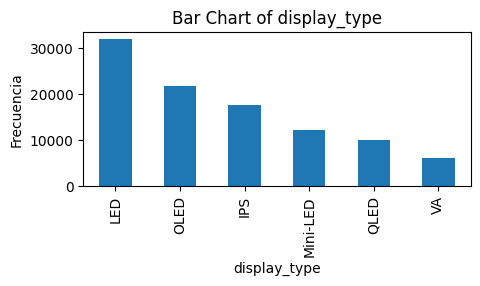

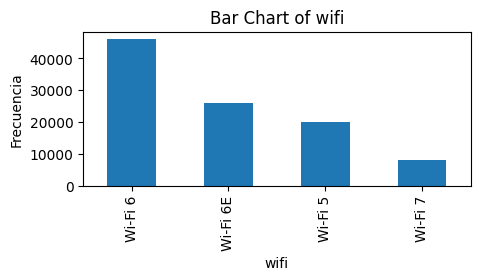

In [18]:
# Bar charts - variable categórica
for col in cat_cols:
    plt.figure(figsize=(5, 2))

    compu_df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f"Bar Chart of {col}")
    plt.ylabel("Frecuencia")
    plt.show()

3. Dibuja un mapa de calor con la matriz de correlación para las variables numéricas del conjunto de datos.
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos.
* Reflexiona sobre cuáles variables representan de manera general la capacidad del hardware y mantenlas; elimina las demás por aportar información redundante.
* Incluye una breve justificación de tus decisiones.

In [19]:
#Matriz de correlación (variables numéricas])
corr_matrix = compu_df.select_dtypes(include=['number']).corr()

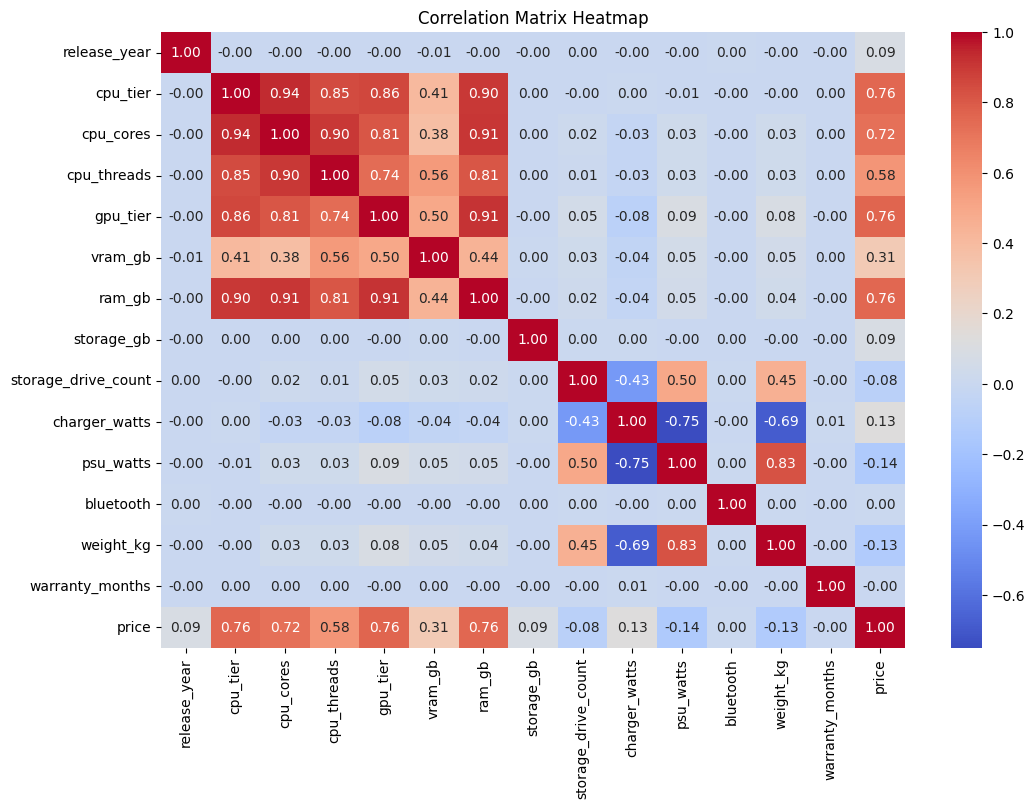

In [20]:
# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

In [21]:
#Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos.
print("Pairs with correlation > 0.9:")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            pair = (corr_matrix.columns[i], corr_matrix.columns[j])
            high_corr_pairs.append(pair)
            print(f"{pair} and {pair[1]}: {corr_matrix.iloc[i, j]:.4f}")

Pairs with correlation > 0.9:
('cpu_tier', 'cpu_cores') and cpu_cores: 0.9374
('cpu_cores', 'ram_gb') and ram_gb: 0.9068
('gpu_tier', 'ram_gb') and ram_gb: 0.9129


In [22]:
# Reducción de Redundancia
# Mantendremos 'ram_gb' como el predictor principal de capacidad de hardware.
# Eliminar las variables redundantes
vars_to_drop = ['cpu_tier', 'cpu_cores', 'cpu_threads', 'gpu_tier']
compu_df.drop(columns=vars_to_drop, inplace=True)

print(f"\nVariables eliminadas: {vars_to_drop}")
print(f"Variables numéricas restantes: {list(compu_df.select_dtypes(include=['number']).columns)}")


Variables eliminadas: ['cpu_tier', 'cpu_cores', 'cpu_threads', 'gpu_tier']
Variables numéricas restantes: ['release_year', 'vram_gb', 'ram_gb', 'storage_gb', 'storage_drive_count', 'charger_watts', 'psu_watts', 'bluetooth', 'weight_kg', 'warranty_months', 'price']


De acuerdo con los datos del mapa de calor se tomaron las siguientes decisiones:

Redundancia:

*   cpu_tier y gpu_tier se eliminan ya que son parte del ram_gb. En el mapa se vé una relación alta entre esas variable por lo que indica que se van a mover muy igual.
*   cpu_cores y cpu_threads tienen una relación alta, especialmente core. En el caso de threads, su relación con el precio (objetivo) es poco por lo que no aporta al resultado.

El predictor físico más sólido es ram_gb

4. Para comenzar con la ingeniería de características, crea una copia del dataframe y asígnala a un nuevo objeto llamado `compu_trans`.
* Calcula cuántos años han pasado desde el lanzamiento de cada computadora y almacénalo en una nueva columna llamada `years_since_release`; luego, elimina la columna original.
* Utiliza `KBinsDiscretizer` para reemplazar la columna `vram_gb` en 4 bins ordinales basados en cuantiles.
* Imprime los valores que delimitan cada bin y haz un histograma para ver la cantidad de observaciones en cada uno, con el fin de entender cómo se agruparon los datos.

In [23]:
# Copia del dataframe original
compu_trans = compu_df.copy()

In [24]:
# Años transcurridos desde el lanzamiento
current_year = datetime.datetime.now().year
compu_trans['years_since_release'] = current_year - compu_trans['release_year']

In [25]:
# Eliminar la columna original release_year [1]
compu_trans.drop(columns=['release_year'], inplace=True)

In [26]:
# Discretización de 'vram_gb' en 4 bins ordinales basados en cuantiles
kbd = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')

compu_trans['vram_gb'] = kbd.fit_transform(compu_trans[['vram_gb']])

In [27]:
#Imprime los valores que delimitan cada bin
print("Límites de los bins para vram_gb:")
print(kbd.bin_edges_)

Límites de los bins para vram_gb:
[array([ 0.,  4.,  6.,  8., 16.])]


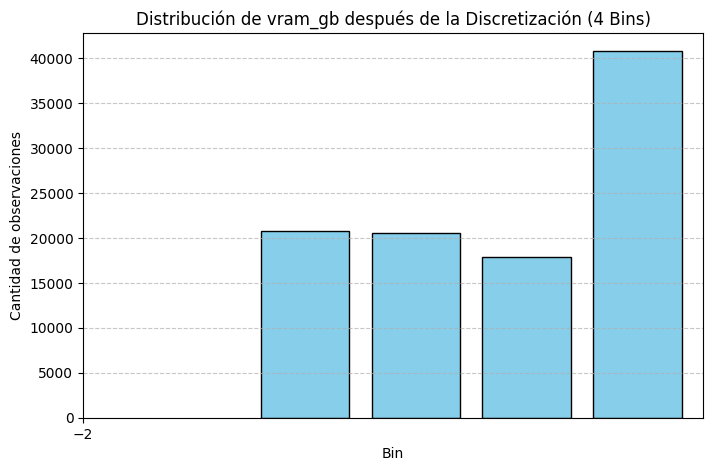

In [28]:
# 5. Visualiza cantidad de observaciones en cada bin
plt.figure(figsize=(8, 5))
plt.hist(compu_trans['vram_gb'], bins=[-0.5, 0.5, 1.5, 2.5, 3.5], rwidth=0.8, color='skyblue', edgecolor='black')
plt.title("Distribución de vram_gb después de la Discretización (4 Bins)")
plt.xlabel("Bin")
plt.ylabel("Cantidad de observaciones")
plt.xticks([7-9])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

5. Observa los histogramas del ejercicio 2. Notarás que en las variables `charger_watts` y `psu_watts` aparece una barra en 0. Analiza por qué ocurre esto y qué significa en relación con el tipo de dispositivo.
* Como estas variables son mutuamente excluyentes, combínalas en una nueva columna llamada `power_watts` que contenga la potencia correspondiente de cada dispositivo y, a continuación, haz un histograma para verificar que la distribución resultante es bimodal.
* Por último, borra las columnas originales `charger_watts` y `psu_watts`.

## **Análisis**

Esto se debe a la arquitectura del dispositivo. Charge_watts está relacionada a Laptos, por ende, su valor en psu_watts es 0. Para el caso de las Desktops tienen un valor de psu_watts pero su valor de charger_watts es 0.

Son variables mutuamente excluyentes (un equipo es uno u otro)

In [29]:
# Combinar las columnas mutuamente excluyentes
compu_trans['power_watts'] = compu_trans['charger_watts'] + compu_trans['psu_watts']

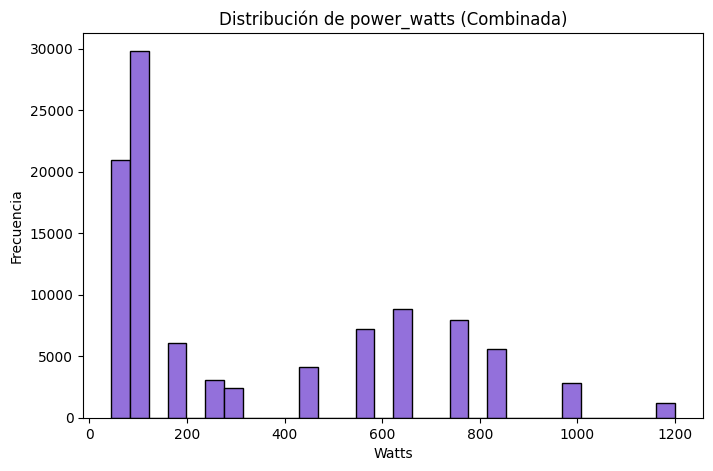

In [30]:
# histograma
plt.figure(figsize=(8, 5))
plt.hist(compu_trans['power_watts'], bins=30, color='mediumpurple', edgecolor='black')
plt.title("Distribución de power_watts (Combinada)")
plt.xlabel("Watts")
plt.ylabel("Frecuencia")
plt.show()

In [31]:
# Eliminar las columnas originales para evitar redundancia
compu_trans.drop(columns=['charger_watts', 'psu_watts'], inplace=True)

print("Primeros registros de la nueva columna power_watts:")
print(compu_trans[['power_watts']].head())

Primeros registros de la nueva columna power_watts:
   power_watts
0          750
1          120
2          850
3          650
4           90


6. Para disminuir el sesgo de la variable `price`, crea tres transformadores: logaritmo, raíz cuadrada y Box - Cox.
* Aplica cada transformador a la variable price, dejando el resultado en variables temporales. El objetivo es comparar los efectos de cada transformación antes de decidir cuál aplicar de manera definitiva sobre las variables continuas del dataframe.
* De la variable original y de cada una de las tres transformaciones se debe mostrar:
  * Histograma: para observar la distribución de los datos.
  * Boxplot: para identificar posibles valores atípicos.
  * Q-Q plot: para evaluar la normalidad de la variable.
  * Skew (sesgo): para cuantificar la asimetría de la distribución.
  * Cantidad de outliers: para conocer cuántos valores extremos existen.
* En función de los resultados obtenidos al comparar las transformaciones, decide cuál logró el mejor efecto sobre la distribución de la variable y aplícala directamente en el dataframe, reemplazando las variables continuas: `weight_kg`, `power_watts` y `price`.

In [32]:
# Variables temporales para comparación (series)
original_price = compu_trans['price']
log_price = np.log(compu_trans['price']) # Logaritmo [2]
sqrt_price = np.sqrt(compu_trans['price']) # Raíz cuadrada [3]

In [33]:
# Transformación Box-Cox (requiere valores positivos)
pt = PowerTransformer(method='box-cox', standardize=False)
boxcox_price = pt.fit_transform(compu_trans[['price']]).flatten()

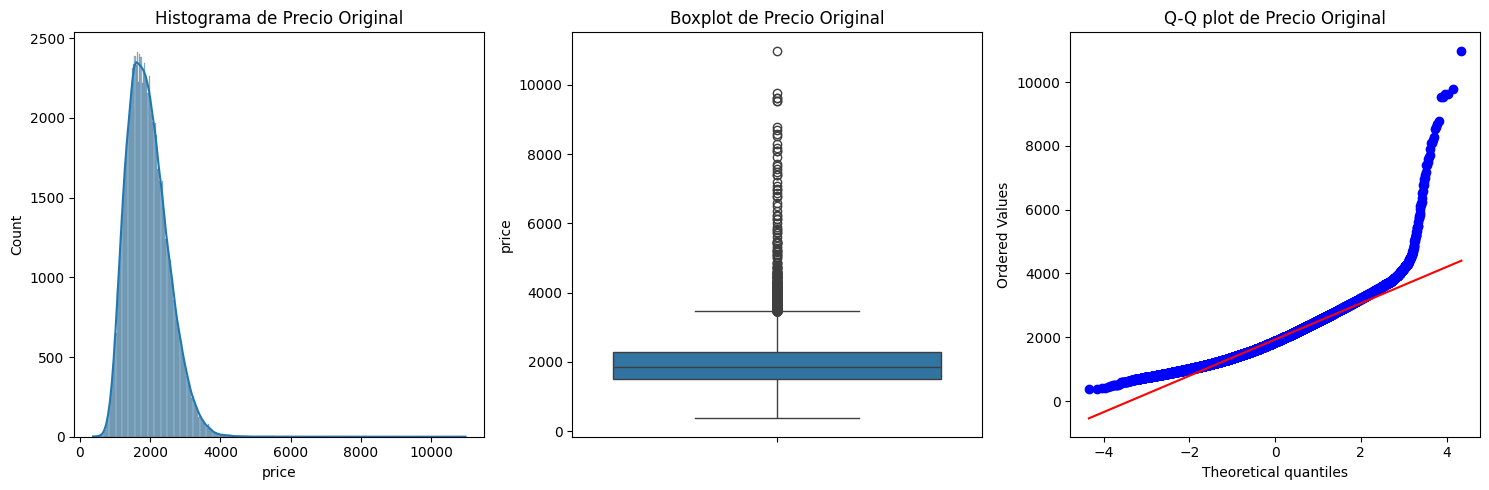

Skewness (Precio Original): 0.9866
Cantidad de outliers (Precio Original): 976




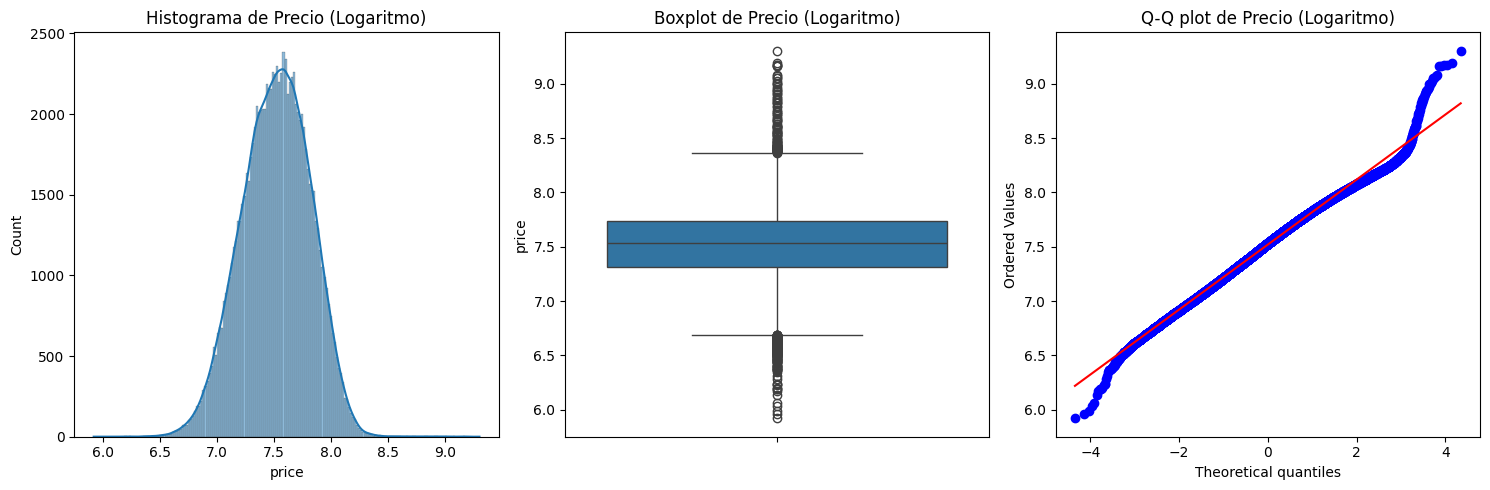

Skewness (Precio (Logaritmo)): -0.1331
Cantidad de outliers (Precio (Logaritmo)): 386




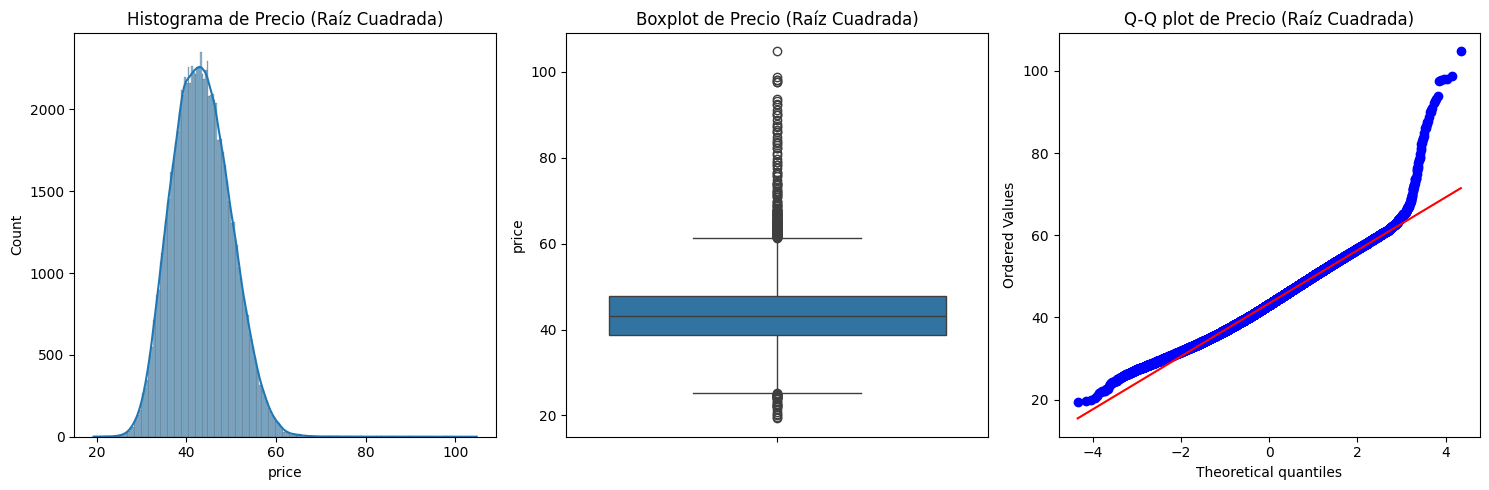

Skewness (Precio (Raíz Cuadrada)): 0.3323
Cantidad de outliers (Precio (Raíz Cuadrada)): 364




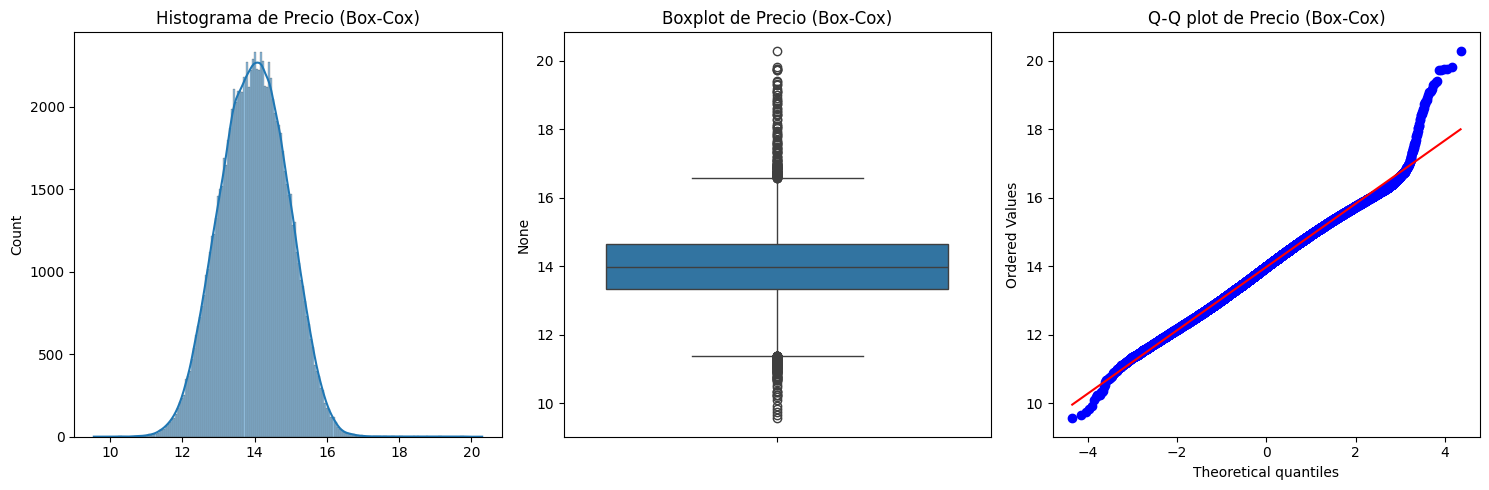

Skewness (Precio (Box-Cox)): -0.0002
Cantidad de outliers (Precio (Box-Cox)): 317




In [34]:
def diagnostic_analysis(series, title):
    plt.figure(figsize=(15, 5))

    # Histogram
    plt.subplot(1, 3, 1)
    sns.histplot(series, kde=True)
    plt.title(f'Histograma de {title}')

    # Boxplot
    plt.subplot(1, 3, 2)
    sns.boxplot(y=series)
    plt.title(f'Boxplot de {title}')

    # Q-Q plot
    plt.subplot(1, 3, 3)
    probplot(series, dist="norm", plot=plt)
    plt.title(f'Q-Q plot de {title}')

    plt.tight_layout()
    plt.show()

    # Skewness
    skew = series.skew()
    print(f"Skewness ({title}): {skew:.4f}")

    # Outliers (using IQR method)
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    outliers = series[(series < (Q1 - 1.5 * IQR)) | (series > (Q3 + 1.5 * IQR))]
    print(f"Cantidad de outliers ({title}): {len(outliers)}")
    print("\n" + "="*60 + "\n")


# Ejecutar diagnósticos
diagnostic_analysis(original_price, "Precio Original")
diagnostic_analysis(log_price, "Precio (Logaritmo)")
diagnostic_analysis(sqrt_price, "Precio (Raíz Cuadrada)")
diagnostic_analysis(pd.Series(boxcox_price), "Precio (Box-Cox)")

## **Análisis**

Box Cox tiene el skewness más cercano a cero lo que significa que tiene una distribución simétrica normal. Skewness = -0.0002

Visualmente se observa en el Q-Q plot que los valores están sobre la línea azul.

In [35]:
# Variables continuas a transformar
cont_vars = ['weight_kg', 'power_watts', 'price']

pt = PowerTransformer(method='box-cox', standardize=False)

compu_trans[cont_vars] = pt.fit_transform(compu_trans[cont_vars])

print("Sesgo (Skewness) después de la transformación Box-Cox:")
print(compu_trans[cont_vars].skew())

Sesgo (Skewness) después de la transformación Box-Cox:
weight_kg      0.213748
power_watts    0.086581
price         -0.000238
dtype: float64


7. Para que todas las variables numéricas estén en la misma escala, aplica `MinMaxScaler` de sklearn a todas las columnas numéricas del dataframe, reemplazando las columnas originales.

In [36]:
# Identificar todas las columnas numéricas actuales en el dataframe
num_cols = compu_trans.select_dtypes(include=['number']).columns
scaler = MinMaxScaler()
compu_trans[num_cols] = scaler.fit_transform(compu_trans[num_cols])

# Verificar que el rango de todas las variables sea ahora entre 0 y 1
print("Después del escalamiento (Min y Max):")
display(compu_trans[num_cols].describe().loc[['min', 'max']])

Después del escalamiento (Min y Max):


,vram_gb,ram_gb,storage_gb,storage_drive_count,bluetooth,weight_kg,warranty_months,price,years_since_release,power_watts
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [37]:
# Mostrar los primeros registros para confirmar el cambio
compu_trans.head()

,device_type,brand,os,form_factor,cpu_brand,gpu_brand,gpu_model,vram_gb,ram_gb,storage_type,storage_gb,storage_drive_count,display_type,wifi,bluetooth,weight_kg,warranty_months,price,years_since_release,power_watts
0,Desktop,Samsung,Windows,ATX,Intel,NVIDIA,RTX 40 60,0.666667,0.058824,NVMe,0.200000,0.000000,LED,Wi-Fi 6,0.818182,0.932995,0.666667,0.328669,0.428571,0.887860
1,Laptop,Samsung,Windows,Mainstream,Intel,NVIDIA,RTX 40 80,1.000000,0.411765,NVMe,0.066667,0.000000,OLED,Wi-Fi 6,1.000000,0.423737,0.000000,0.471202,0.428571,0.357238
2,Desktop,Lenovo,macOS,SFF,AMD,NVIDIA,RTX 40 50,0.333333,0.000000,NVMe,0.066667,0.333333,LED,Wi-Fi 6,0.727273,0.834353,0.333333,0.415246,0.142857,0.918578
3,Desktop,Dell,Windows,ATX,AMD,AMD,RX 7000 60,0.666667,0.058824,HDD,0.066667,0.333333,IPS,Wi-Fi 6,0.909091,0.795505,0.666667,0.318122,0.142857,0.851953
4,Laptop,Gigabyte,Linux,Gaming,AMD,NVIDIA,RTX 30 80 Ti,1.000000,0.647059,NVMe,0.000000,0.000000,Mini-LED,Wi-Fi 6,0.909091,0.280423,0.000000,0.520800,0.142857,0.258382


8. Aunque `wifi` es una variable categórica, sus categorías tienen un orden natural (Wi-Fi 5 < Wi-Fi 6 < Wi-Fi 6E < Wi-Fi 7). Codifícala usando `OrdinalEncoder`.
* Luego, escala la variable codificada entre 0 y 1 con `MinMaxScaler`, para que quede en la misma escala que las variables numéricas del dataframe.

Nota: Ambos cambios deben efectuarse sobre la columna original, de manera que quede una única columna `wifi` con toda la información transformada.

In [38]:
# Codificacion Ordinal
wifi_categories = [['Wi-Fi 5', 'Wi-Fi 6', 'Wi-Fi 6E', 'Wi-Fi 7']]
ord_enc = OrdinalEncoder(categories=wifi_categories)

In [39]:
# Escala variable codificada MinMaxScaler
compu_trans['wifi'] = ord_enc.fit_transform(compu_trans[['wifi']])
mm_scaler = MinMaxScaler()
compu_trans['wifi'] = mm_scaler.fit_transform(compu_trans[['wifi']])


In [40]:

print("Escala'wifi':")
print(compu_trans['wifi'].unique())
print("\nData:")
print(compu_trans['wifi'].head())

Escala'wifi':
[0.33333333 0.         0.66666667 1.        ]

Data:
0    0.333333
1    0.333333
2    0.333333
3    0.333333
4    0.333333
Name: wifi, dtype: float64


9. La variable `gpu_model` tiene muchas categorías. Usar *One-Hot Encoding* aumentaría significativamente la dimensionalidad del dataframe. Por ello, utiliza `BinaryEncoder` para codificarla.
* Guarda el resultado en un dataframe llamado `bin_df`. Más adelante, lo combinarás con `compu_transf` para integrar las variables codificadas.

In [41]:
# Usar One-Hot Encoding
be = BinaryEncoder(cols=['gpu_model'])
bin_df = be.fit_transform(compu_trans[['gpu_model']])


In [42]:
display(bin_df.head())

,gpu_model_0,gpu_model_1,gpu_model_2,gpu_model_3,gpu_model_4,gpu_model_5
0,0,0,0,0,0,1
1,0,0,0,0,1,0
2,0,0,0,0,1,1
3,0,0,0,1,0,0
4,0,0,0,1,0,1


10. Usa `OneHotEncoder` para codificar las variables categóricas restantes. Asegúrate de usar `drop='first'` para evitar la multicolinealidad y guarda el resultado en un dataframe llamado `ohe_df`
* Combina el dataframe `compu_transf` con las variables categóricas que fueron codificadas en `bin_df` y `ohe_df`. No olvides eliminar las variables originales.
* Usa `describe()` sobre el dataframe resultante para corroborar que todas las columnas estén escaladas entre 0 y 1 y que no queden variables categóricas sin codificar.

In [43]:
# Identificar las variables categóricas restantes (excluyendo gpu_model)
cat_remaining = compu_trans.select_dtypes(include=['object']).columns.tolist()
if 'gpu_model' in cat_remaining:
    cat_remaining.remove('gpu_model')

display(cat_remaining)

['device_type',
 'brand',
 'os',
 'form_factor',
 'cpu_brand',
 'gpu_brand',
 'storage_type',
 'display_type']

In [44]:
compu_trans.dtypes.value_counts()

,count
float64,11
object,9


In [45]:
# OneHotEncoder
ohe = OneHotEncoder(drop='first', sparse_output=False)
ohe_results = ohe.fit_transform(compu_trans[cat_remaining])

ohe_df = pd.DataFrame(ohe_results, columns=ohe.get_feature_names_out(cat_remaining))

In [46]:
# Eliminar variables originales y combinar dataframes
compu_final = compu_trans.drop(columns=cat_remaining + ['gpu_model'])
#Concatenamos horizontalmente (axis=1)
compu_final = pd.concat([compu_final.reset_index(drop=True),
                         bin_df.reset_index(drop=True),
                         ohe_df.reset_index(drop=True)], axis=1)

In [47]:
display(compu_final.describe().T[['min', 'max']])

,min,max
vram_gb,0.0,1.0
ram_gb,0.0,1.0
storage_gb,0.0,1.0
storage_drive_count,0.0,1.0
wifi,0.0,1.0
bluetooth,0.0,1.0
weight_kg,0.0,1.0
warranty_months,0.0,1.0
price,0.0,1.0
years_since_release,0.0,1.0


In [48]:
compu_final.dtypes.value_counts()

,count
float64,46
int64,6


**No quedan columnas de tipo objeto (categóricas); todas han sido codificadas a valores numéricos (float64, int64)**